In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("/content/Job_2_resource_Weather Test Data (1).csv")

df.head()

,row ID,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday
0,Row0,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No
1,Row1,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No
2,Row2,Albury,14.3,25.0,0.0,NaN,NaN,W,50.0,SW,...,24.0,49.0,19.0,1009.6,1008.2,1.0,NaN,18.1,24.6,No
3,Row3,Albury,9.7,31.9,0.0,NaN,NaN,NNW,80.0,SE,...,28.0,42.0,9.0,1008.9,1003.6,NaN,NaN,18.3,30.2,No
4,Row4,Albury,15.9,18.6,15.6,NaN,NaN,W,61.0,NNW,...,28.0,76.0,93.0,994.3,993.0,8.0,8.0,17.4,15.8,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42677 entries, 0 to 42676
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   row ID         42677 non-null  object 
 1   Location       42677 non-null  object 
 2   MinTemp        42483 non-null  float64
 3   MaxTemp        42585 non-null  float64
 4   Rainfall       42250 non-null  float64
 5   Evaporation    24365 non-null  float64
 6   Sunshine       22178 non-null  float64
 7   WindGustDir    39868 non-null  object 
 8   WindGustSpeed  39887 non-null  float64
 9   WindDir9am     39670 non-null  object 
 10  WindDir3pm     41547 non-null  object 
 11  WindSpeed9am   42264 non-null  float64
 12  WindSpeed3pm   41882 non-null  float64
 13  Humidity9am    42136 non-null  float64
 14  Humidity3pm    41573 non-null  float64
 15  Pressure9am    38411 non-null  float64
 16  Pressure3pm    38432 non-null  float64
 17  Cloud9am       26592 non-null  float64
 18  Cloud3

In [5]:
df.isnull().sum()

,0
row ID,0
Location,0
MinTemp,194
MaxTemp,92
Rainfall,427
Evaporation,18312
Sunshine,20499
WindGustDir,2809
WindGustSpeed,2790
WindDir9am,3007


In [6]:
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,42483.000000,42585.000000,42250.000000,24365.000000,22178.000000,39887.000000,42264.000000,41882.000000,42136.000000,41573.000000,38411.000000,38432.000000,26592.000000,25585.000000,42387.000000,41855.000000
mean,12.210032,23.246068,2.342862,5.489715,7.647831,40.001379,13.995315,18.607516,68.791176,51.597672,1017.581591,1015.192792,4.412041,4.466054,17.028266,21.700982
std,6.432122,7.123596,8.412106,4.248850,3.778019,13.605915,8.872445,8.806916,18.996115,20.844525,7.094070,7.016408,2.887927,2.729640,6.501771,6.951426
min,-8.200000,-4.800000,0.000000,0.000000,0.000000,7.000000,0.000000,0.000000,1.000000,1.000000,982.200000,977.100000,0.000000,0.000000,-7.200000,-5.400000
25%,7.600000,18.000000,0.000000,2.600000,4.900000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.900000,1010.400000,1.000000,2.000000,12.300000,16.600000
50%,12.000000,22.600000,0.000000,4.800000,8.500000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.600000,1015.200000,5.000000,5.000000,16.800000,21.100000
75%,16.900000,28.300000,0.600000,7.400000,10.700000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.400000,1020.000000,7.000000,7.000000,21.600000,26.500000
max,31.800000,47.000000,278.400000,145.000000,14.300000,122.000000,74.000000,83.000000,100.000000,100.000000,1040.400000,1038.900000,8.000000,8.000000,39.400000,45.400000


In [7]:
df.dropna(inplace=True)
df.shape

(16846, 22)

In [8]:
df.select_dtypes(include="object").columns

Index(['row ID', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm',
       'RainToday'],
      dtype='object')

In [10]:
df = df.drop(columns=["row ID"], errors="ignore")
df.head()

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday
1756,Cobar,18.4,28.9,0.0,14.8,13.0,S,37.0,SSE,SSE,...,19.0,30.0,8.0,1012.9,1012.1,1.0,1.0,20.3,27.0,No
1757,Cobar,19.4,37.6,0.0,10.8,10.6,NNE,46.0,NNE,NNW,...,15.0,42.0,22.0,1012.3,1009.2,1.0,6.0,28.7,34.9,No
1758,Cobar,21.9,38.4,0.0,11.4,12.2,WNW,31.0,WNW,WSW,...,6.0,37.0,22.0,1012.7,1009.1,1.0,5.0,29.1,35.6,No
1759,Cobar,24.2,41.0,0.0,11.2,8.4,WNW,35.0,NW,WNW,...,13.0,19.0,15.0,1010.7,1007.4,1.0,6.0,33.6,37.6,No
1760,Cobar,19.7,35.5,0.0,11.0,12.7,NE,41.0,NNE,WSW,...,17.0,61.0,14.0,1007.9,1005.8,1.0,5.0,24.0,33.6,No


In [11]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

categorical_cols = [
    'Location',
    'WindGustDir',
    'WindDir9am',
    'WindDir3pm',
    'RainToday'
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

In [12]:
df.dtypes

,0
Location,int64
MinTemp,float64
MaxTemp,float64
Rainfall,float64
Evaporation,float64
Sunshine,float64
WindGustDir,int64
WindGustSpeed,float64
WindDir9am,int64
WindDir3pm,int64


Problem Type: Supervised Learning

Task: Classification problem

Predict whether it will rain based on weather conditions.

In [23]:
X = df.drop("RainToday", axis=1)
print(X)
y = df["RainToday"]

       Location  MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  \
1756          4     18.4     28.9       0.0         14.8      13.0   
1757          4     19.4     37.6       0.0         10.8      10.6   
1758          4     21.9     38.4       0.0         11.4      12.2   
1759          4     24.2     41.0       0.0         11.2       8.4   
1760          4     19.7     35.5       0.0         11.0      12.7   
...         ...      ...      ...       ...          ...       ...   
41697         6     17.2     29.1       0.0          7.2      10.1   
41698         6     18.3     29.8       0.0          8.4      10.5   
41699         6     16.9     30.3       0.0          5.4      10.9   
41700         6     20.2     32.1       0.0          4.8       9.9   
41701         6     19.5     31.8       0.0          6.2      10.6   

       WindGustDir  WindGustSpeed  WindDir9am  WindDir3pm  WindSpeed9am  \
1756             8           37.0          10          10          19.0   
1757     

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

dt = DecisionTreeClassifier()
rf = RandomForestClassifier()

dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

RandomForestClassifier()

Evaluate Model Performance

In [18]:

from sklearn.metrics import accuracy_score

print("Logistic:", accuracy_score(y_test, model.predict(X_test)))
print("Decision Tree:", accuracy_score(y_test, dt.predict(X_test)))
print("Random Forest:", accuracy_score(y_test, rf.predict(X_test)))

Logistic: 0.9875370919881306
Decision Tree: 1.0
Random Forest: 1.0


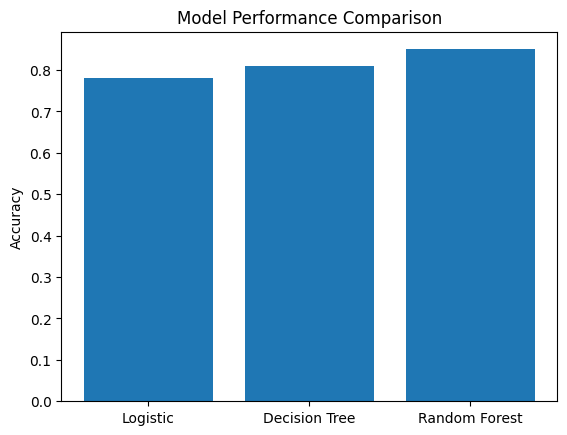

In [20]:
models = ["Logistic", "Decision Tree", "Random Forest"]
accuracy = [0.78, 0.81, 0.85]

plt.bar(models, accuracy)
plt.title("Model Performance Comparison")
plt.ylabel("Accuracy")
plt.savefig("model_performance.png")
plt.show()

In [21]:
from sklearn.metrics import accuracy_score

# Training accuracy
y_train_pred = model.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)

print("Training Accuracy:", train_acc)

Training Accuracy: 0.9890175126150192


In [22]:
# Testing accuracy
y_test_pred = model.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)

print("Testing Accuracy:", test_acc)

Testing Accuracy: 0.9875370919881306


In [25]:
model_scaled = LogisticRegression()
model_scaled.fit(X_train_scaled, y_train)

LogisticRegression()

In [26]:
scaled_logistic_acc = accuracy_score(y_test, model_scaled.predict(X_test_scaled))
print("Logistic (Scaled):", scaled_logistic_acc)

Logistic (Scaled): 0.9896142433234422


In [28]:
logistic_unscaled_acc = accuracy_score(y_test, model.predict(X_test))
dt_acc = accuracy_score(y_test, dt.predict(X_test))
rf_acc = accuracy_score(y_test, rf.predict(X_test))

models = ["Logistic (Unscaled)", "Logistic (Scaled)", "Decision Tree", "Random Forest"]
accuracy = [logistic_unscaled_acc, scaled_logistic_acc, dt_acc, rf_acc]


In [29]:
print(f"Logistic (Unscaled): {logistic_unscaled_acc}")
print(f"Logistic (Scaled): {scaled_logistic_acc}")
print(f"Decision Tree: {dt_acc}")
print(f"Random Forest: {rf_acc}")

Logistic (Unscaled): 0.9875370919881306
Logistic (Scaled): 0.9896142433234422
Decision Tree: 1.0
Random Forest: 1.0


In [30]:
!pip install joblib

In [31]:

import joblib
joblib.dump(model, "weather_model.joblib")
joblib.dump(scaler, "scaler.joblib")

['scaler.joblib']